# Datathon Starter Notebook
This notebook will guide you through a fast, competitive workflow for tabular data modeling.

In [47]:
# Import libraries and load data
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report
df = pd.read_csv('heart (1).csv')
df.head()

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0


## Step 1: Data Exploration
Let's explore the dataset to understand its structure and spot any issues.

In [48]:
# Quick data overview
print('Shape:', df.shape)
print('Columns:', df.columns.tolist())
df.info()
df.describe()

Shape: (918, 12)
Columns: ['Age', 'Sex', 'ChestPainType', 'RestingBP', 'Cholesterol', 'FastingBS', 'RestingECG', 'MaxHR', 'ExerciseAngina', 'Oldpeak', 'ST_Slope', 'HeartDisease']
<class 'pandas.DataFrame'>
RangeIndex: 918 entries, 0 to 917
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Age             918 non-null    int64  
 1   Sex             918 non-null    str    
 2   ChestPainType   918 non-null    str    
 3   RestingBP       918 non-null    int64  
 4   Cholesterol     918 non-null    int64  
 5   FastingBS       918 non-null    int64  
 6   RestingECG      918 non-null    str    
 7   MaxHR           918 non-null    int64  
 8   ExerciseAngina  918 non-null    str    
 9   Oldpeak         918 non-null    float64
 10  ST_Slope        918 non-null    str    
 11  HeartDisease    918 non-null    int64  
dtypes: float64(1), int64(6), str(5)
memory usage: 86.2 KB


,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease
count,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000
mean,53.510893,132.396514,198.799564,0.233115,136.809368,0.887364,0.553377
std,9.432617,18.514154,109.384145,0.423046,25.460334,1.066570,0.497414
min,28.000000,0.000000,0.000000,0.000000,60.000000,-2.600000,0.000000
25%,47.000000,120.000000,173.250000,0.000000,120.000000,0.000000,0.000000
50%,54.000000,130.000000,223.000000,0.000000,138.000000,0.600000,1.000000
75%,60.000000,140.000000,267.000000,0.000000,156.000000,1.500000,1.000000
max,77.000000,200.000000,603.000000,1.000000,202.000000,6.200000,1.000000


Missing values per column:
Age               0
Sex               0
ChestPainType     0
RestingBP         0
Cholesterol       0
FastingBS         0
RestingECG        0
MaxHR             0
ExerciseAngina    0
Oldpeak           0
ST_Slope          0
HeartDisease      0
dtype: int64


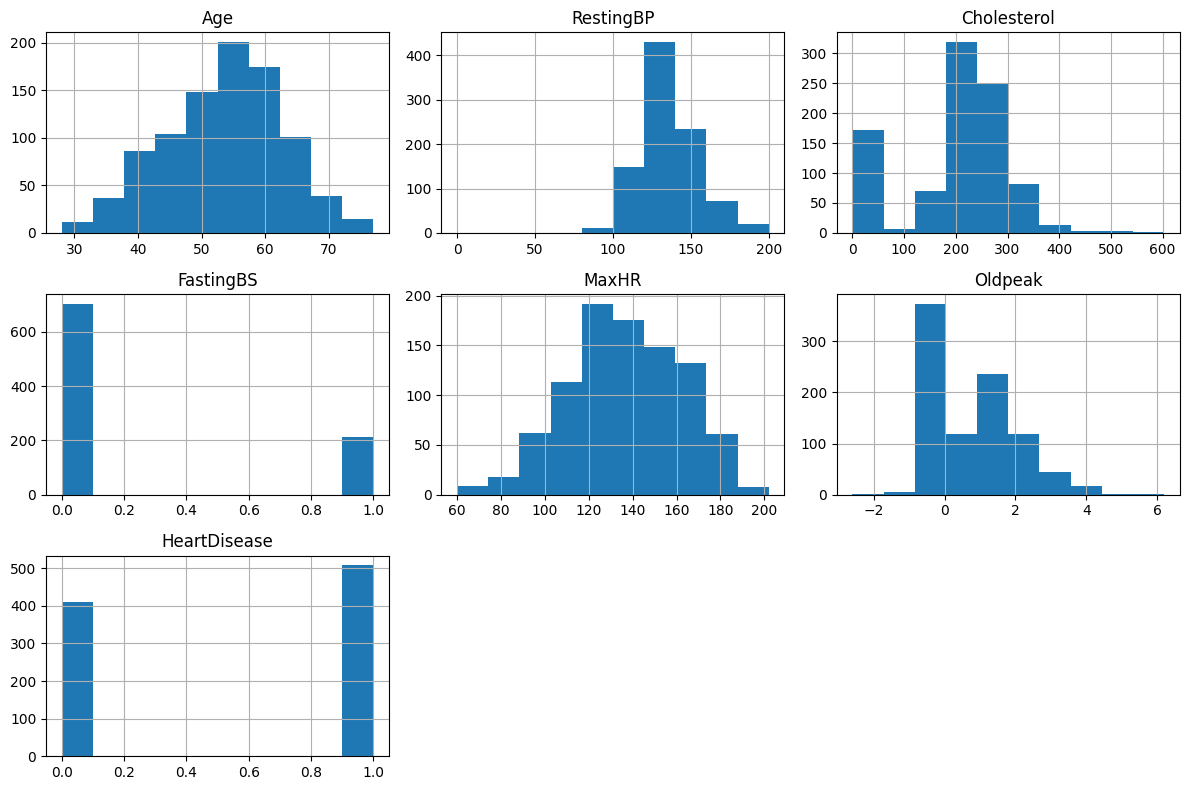

In [49]:
# Check for missing values and visualize distributions
print('Missing values per column:')
print(df.isnull().sum())
df.hist(figsize=(12,8))
plt.tight_layout()
plt.show()

## Step 2: Data Cleaning & Feature Engineering
- Handle missing values, outliers, and categorical variables.
- Create new features if possible.

In [50]:
# Example: Fill missing values and encode categoricals
# Fill missing values (if any)
df = df.fillna(df.median(numeric_only=True))
# Identify categorical columns
categorical_cols = df.select_dtypes(include=['object', 'category']).columns.tolist()
# Encode categoricals
for col in categorical_cols:
    df[col] = df[col].astype('category').cat.codes
df.head()

C:\Users\varsh\AppData\Local\Temp\ipykernel_33352\908284466.py:5: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = df.select_dtypes(include=['object', 'category']).columns.tolist()


,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,1,1,140,289,0,1,172,0,0.0,2,0
1,49,0,2,160,180,0,1,156,0,1.0,1,1
2,37,1,1,130,283,0,2,98,0,0.0,2,0
3,48,0,0,138,214,0,1,108,1,1.5,1,1
4,54,1,2,150,195,0,1,122,0,0.0,2,0


## Step 3: Baseline Model
Let's build a quick baseline model to set a performance benchmark.

In [51]:
# Split data into features and target
target_col = 'HeartDisease'  # Corrected target column name
X = df.drop(target_col, axis=1)
y = df[target_col]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [52]:
# Baseline: Logistic Regression
from sklearn.linear_model import LogisticRegression
lr = LogisticRegression(max_iter=1000)
lr.fit(X_train, y_train)
y_pred = lr.predict(X_test)
print('Accuracy:', accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.842391304347826
              precision    recall  f1-score   support

           0       0.77      0.88      0.82        77
           1       0.91      0.81      0.86       107

    accuracy                           0.84       184
   macro avg       0.84      0.85      0.84       184
weighted avg       0.85      0.84      0.84       184



## Step 4: Advanced Modeling
Try powerful models like XGBoost and LightGBM for better performance.

In [53]:
# XGBoost Model
from xgboost import XGBClassifier
xgb = XGBClassifier(use_label_encoder=False, eval_metric='logloss')
xgb.fit(X_train, y_train)
y_pred_xgb = xgb.predict(X_test)
print('XGBoost Accuracy:', accuracy_score(y_test, y_pred_xgb))
print(classification_report(y_test, y_pred_xgb))

XGBoost Accuracy: 0.8695652173913043
              precision    recall  f1-score   support

           0       0.81      0.90      0.85        77
           1       0.92      0.85      0.88       107

    accuracy                           0.87       184
   macro avg       0.87      0.87      0.87       184
weighted avg       0.87      0.87      0.87       184



c:\Users\varsh\Downloads\Epoch\.venv\Lib\site-packages\xgboost\training.py:200: UserWarning: [11:39:24] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


# Heart Disease Risk Prediction Tool
This section implements a user-focused prediction tool with explainable AI and actionable insights.

In [54]:
# User input simulation (replace with real input in app)
user_data = {
    'Age': 45,
    'Sex': 1,  # 1=M, 0=F
    'ChestPainType': 2,
    'RestingBP': 130,
    'Cholesterol': 250,
    'FastingBS': 0,
    'RestingECG': 1,
    'MaxHR': 150,
    'ExerciseAngina': 0,
    'Oldpeak': 1.0,
    'ST_Slope': 1
}
user_df = pd.DataFrame([user_data])
# Predict risk with XGBoost model
risk = xgb.predict(user_df)[0]
prob = xgb.predict_proba(user_df)[0][1]
print(f'Predicted Heart Disease Risk: {risk} (Probability: {prob:.2f})')

Predicted Heart Disease Risk: 0 (Probability: 0.06)


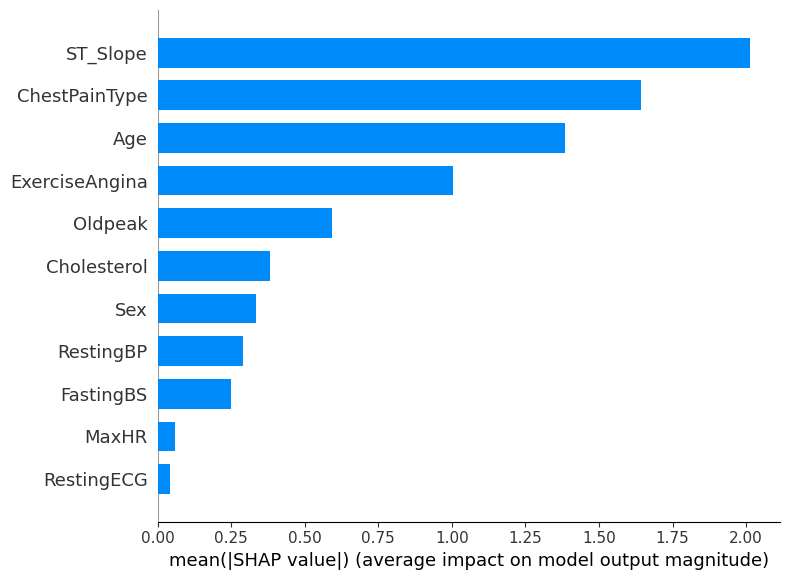

In [55]:
# Explainable AI: SHAP values for user prediction
import shap
explainer = shap.Explainer(xgb, X_train)
shap_values = explainer(user_df)
shap.summary_plot(shap_values, user_df, plot_type='bar')

# Advanced Modeling & Feature Engineering
This section covers feature engineering, hyperparameter tuning, ensemble methods, cross-validation, interpretability, AutoML, and class imbalance handling.

In [56]:
# Feature Engineering: Age bins, cholesterol ratio, interaction terms, polynomial features
from sklearn.preprocessing import PolynomialFeatures
df['AgeBin'] = pd.cut(df['Age'], bins=[0, 40, 50, 60, 100], labels=[0,1,2,3])
df['Chol_Ratio'] = df['Cholesterol'] / (df['Age'] + 1)
df['BP_Chol_Interaction'] = df['RestingBP'] * df['Cholesterol']
poly = PolynomialFeatures(degree=2, include_bias=False)
poly_features = poly.fit_transform(df[['Age', 'RestingBP', 'Cholesterol', 'MaxHR', 'Oldpeak']])
poly_feature_names = poly.get_feature_names_out(['Age', 'RestingBP', 'Cholesterol', 'MaxHR', 'Oldpeak'])
poly_df = pd.DataFrame(poly_features, columns=poly_feature_names, index=df.index)
df = pd.concat([df, poly_df], axis=1)
df.head()

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,...,RestingBP^2,RestingBP Cholesterol,RestingBP MaxHR,RestingBP Oldpeak,Cholesterol^2,Cholesterol MaxHR,Cholesterol Oldpeak,MaxHR^2,MaxHR Oldpeak,Oldpeak^2
0,40,1,1,140,289,0,1,172,0,0.0,...,19600.0,40460.0,24080.0,0.0,83521.0,49708.0,0.0,29584.0,0.0,0.00
1,49,0,2,160,180,0,1,156,0,1.0,...,25600.0,28800.0,24960.0,160.0,32400.0,28080.0,180.0,24336.0,156.0,1.00
2,37,1,1,130,283,0,2,98,0,0.0,...,16900.0,36790.0,12740.0,0.0,80089.0,27734.0,0.0,9604.0,0.0,0.00
3,48,0,0,138,214,0,1,108,1,1.5,...,19044.0,29532.0,14904.0,207.0,45796.0,23112.0,321.0,11664.0,162.0,2.25
4,54,1,2,150,195,0,1,122,0,0.0,...,22500.0,29250.0,18300.0,0.0,38025.0,23790.0,0.0,14884.0,0.0,0.00


In [57]:
# Hyperparameter Tuning: GridSearchCV for XGBoost and Logistic Regression
from sklearn.model_selection import GridSearchCV
from xgboost import XGBClassifier
from sklearn.linear_model import LogisticRegression
param_grid_xgb = {
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.1, 0.2],
    'n_estimators': [100, 200],
    'subsample': [0.8, 1.0]
}
xgb_grid = GridSearchCV(XGBClassifier(use_label_encoder=False, eval_metric='logloss'), param_grid_xgb, cv=3, scoring='accuracy')
xgb_grid.fit(X_train, y_train)
print('Best XGBoost Params:', xgb_grid.best_params_)
param_grid_lr = {
    'C': [0.1, 1, 10],
    'penalty': ['l1', 'l2'],
    'solver': ['liblinear']
}
lr_grid = GridSearchCV(LogisticRegression(max_iter=1000, solver='liblinear'), param_grid_lr, cv=3, scoring='accuracy')
lr_grid.fit(X_train, y_train)
print('Best Logistic Regression Params:', lr_grid.best_params_)

c:\Users\varsh\Downloads\Epoch\.venv\Lib\site-packages\xgboost\training.py:200: UserWarning: [11:39:25] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
c:\Users\varsh\Downloads\Epoch\.venv\Lib\site-packages\xgboost\training.py:200: UserWarning: [11:39:25] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
c:\Users\varsh\Downloads\Epoch\.venv\Lib\site-packages\xgboost\training.py:200: UserWarning: [11:39:25] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
c:\Users\varsh\Downloads\Epoch\.venv\Lib\site-packages\xgboost\training.py:200: UserWarning: [11:39:25] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_

Best XGBoost Params: {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 100, 'subsample': 1.0}


c:\Users\varsh\Downloads\Epoch\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\Users\varsh\Downloads\Epoch\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1160: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(
c:\Users\varsh\Downloads\Epoch\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf

Best Logistic Regression Params: {'C': 1, 'penalty': 'l1', 'solver': 'liblinear'}


c:\Users\varsh\Downloads\Epoch\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\Users\varsh\Downloads\Epoch\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\Users\varsh\Downloads\Epoch\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To 

In [58]:
# Ensemble Methods: VotingClassifier, stacking, blending
from sklearn.ensemble import RandomForestClassifier, VotingClassifier, StackingClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier
rf = RandomForestClassifier(n_estimators=100, random_state=42)
lgbm = LGBMClassifier(random_state=42)
cat = CatBoostClassifier(verbose=0, random_state=42)
voting = VotingClassifier(estimators=[('xgb', xgb_grid.best_estimator_), ('rf', rf), ('lgbm', lgbm), ('cat', cat)], voting='soft')
voting.fit(X_train, y_train)
y_pred_voting = voting.predict(X_test)
print('VotingClassifier Accuracy:', accuracy_score(y_test, y_pred_voting))
stacking = StackingClassifier(estimators=[('rf', rf), ('lgbm', lgbm), ('cat', cat)], final_estimator=LogisticRegression(solver='liblinear'))
stacking.fit(X_train, y_train)
y_pred_stacking = stacking.predict(X_test)
print('StackingClassifier Accuracy:', accuracy_score(y_test, y_pred_stacking))

c:\Users\varsh\Downloads\Epoch\.venv\Lib\site-packages\xgboost\training.py:200: UserWarning: [11:39:42] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


[LightGBM] [Info] Number of positive: 401, number of negative: 333
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000342 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 358
[LightGBM] [Info] Number of data points in the train set: 734, number of used features: 11
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.546322 -> initscore=0.185819
[LightGBM] [Info] Start training from score 0.185819
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best g

In [59]:
# Cross-Validation: StratifiedKFold
from sklearn.model_selection import StratifiedKFold, cross_val_score
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(voting, X, y, cv=skf, scoring='accuracy')
print('VotingClassifier CV Scores:', cv_scores)
print('Mean CV Score:', np.mean(cv_scores))

c:\Users\varsh\Downloads\Epoch\.venv\Lib\site-packages\xgboost\training.py:200: UserWarning: [11:40:06] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


[LightGBM] [Info] Number of positive: 406, number of negative: 328
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000124 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 371
[LightGBM] [Info] Number of data points in the train set: 734, number of used features: 11
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.553134 -> initscore=0.213340
[LightGBM] [Info] Start training from score 0.213340
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[

c:\Users\varsh\Downloads\Epoch\.venv\Lib\site-packages\xgboost\training.py:200: UserWarning: [11:40:10] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


[LightGBM] [Info] Number of positive: 406, number of negative: 328
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000252 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 365
[LightGBM] [Info] Number of data points in the train set: 734, number of used features: 11
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.553134 -> initscore=0.213340
[LightGBM] [Info] Start training from score 0.213340
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best g

c:\Users\varsh\Downloads\Epoch\.venv\Lib\site-packages\xgboost\training.py:200: UserWarning: [11:40:14] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


[LightGBM] [Info] Number of positive: 406, number of negative: 328
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000102 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 369
[LightGBM] [Info] Number of data points in the train set: 734, number of used features: 11
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.553134 -> initscore=0.213340
[LightGBM] [Info] Start training from score 0.213340
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[

c:\Users\varsh\Downloads\Epoch\.venv\Lib\site-packages\xgboost\training.py:200: UserWarning: [11:40:18] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


[LightGBM] [Info] Number of positive: 407, number of negative: 328
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000204 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 369
[LightGBM] [Info] Number of data points in the train set: 735, number of used features: 11
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.553741 -> initscore=0.215800
[LightGBM] [Info] Start training from score 0.215800
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[

c:\Users\varsh\Downloads\Epoch\.venv\Lib\site-packages\xgboost\training.py:200: UserWarning: [11:40:22] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


[LightGBM] [Info] Number of positive: 407, number of negative: 328
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000146 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 362
[LightGBM] [Info] Number of data points in the train set: 735, number of used features: 11
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.553741 -> initscore=0.215800
[LightGBM] [Info] Start training from score 0.215800
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[

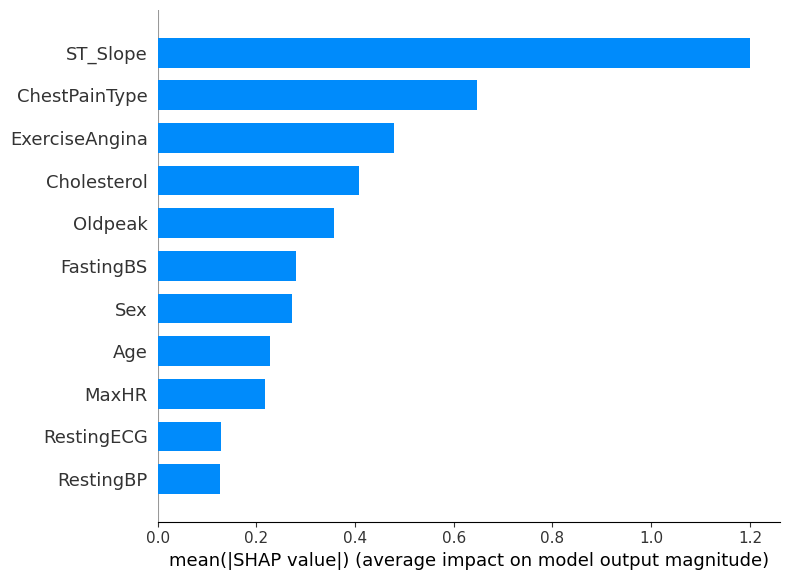

RandomForestClassifier does not have feature_importances_ or is not fitted.


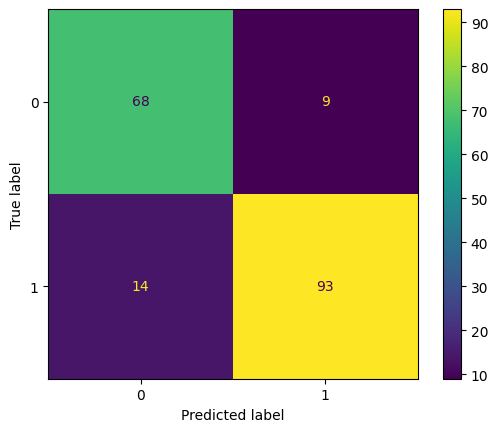

In [60]:
# Model Interpretability: SHAP global feature importance (XGBoost), confusion matrix, error analysis
import shap
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
explainer = shap.Explainer(xgb_grid.best_estimator_, X_train)
shap_values = explainer(X_test)
shap.summary_plot(shap_values, X_test, plot_type='bar')
y_pred = voting.predict(X_test)
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
# Feature importance for ensemble (VotingClassifier)
if hasattr(rf, 'feature_importances_') and hasattr(rf, 'fit') and hasattr(rf, 'predict') and hasattr(rf, 'score'):
    if hasattr(rf, 'n_features_') and rf.n_features_ > 0:
        importances = rf.feature_importances_
        import matplotlib.pyplot as plt
        plt.figure(figsize=(10,6))
        plt.bar(X.columns, importances)
        plt.xticks(rotation=90)
        plt.title('RandomForest Feature Importances (VotingClassifier)')
        plt.show()
    else:
        print('RandomForestClassifier is not fitted yet. Please fit before using feature_importances_.')
else:
    print('RandomForestClassifier does not have feature_importances_ or is not fitted.')

In [62]:
# Automated Machine Learning (AutoML): TPOT
try:
    from tpot import TPOTClassifier
    tpot = TPOTClassifier(generations=5, population_size=20, verbosity=2, random_state=42)
    tpot.fit(X_train, y_train)
    print('TPOT Best Pipeline:', tpot.fitted_pipeline_)
    print('TPOT Test Accuracy:', tpot.score(X_test, y_test))
except ModuleNotFoundError as e:
    print('TPOT is not installed or missing dependencies:', e)
except Exception as e:
    print('TPOT error:', e)

TPOT is not installed or missing dependencies: No module named 'pkg_resources'


In [63]:
# Class Imbalance Handling: SMOTE
try:
    from imblearn.over_sampling import SMOTE
    smote = SMOTE(random_state=42)
    X_resampled, y_resampled = smote.fit_resample(X, y)
    print('Resampled class distribution:', np.bincount(y_resampled))
except ModuleNotFoundError as e:
    print('imblearn is not installed:', e)
except Exception as e:
    print('SMOTE error:', e)

Resampled class distribution: [508 508]


# Personalized Lifestyle Recommendations
Based on the user's health metrics, provide specific, actionable recommendations to reduce heart disease risk.

In [64]:
# Generate Personalized Lifestyle Recommendations
def get_lifestyle_recommendations(user_data, risk_probability):
    recommendations = {
        'high_risk': [],
        'moderate_risk': [],
        'optimal': [],
        'estimated_improvement': 0.0
    }
    
    # Define healthy ranges for each metric
    healthy_ranges = {
        'Age': (18, 65),
        'RestingBP': (90, 120),  # Systolic BP
        'Cholesterol': (0, 200),
        'MaxHR': (120, 200),  # Should be higher for good cardiovascular fitness
        'Oldpeak': (0, 1.0)  # ST depression induced by exercise
    }
    
    # Metabolic score for combined metrics
    risk_score = 0
    total_metrics = 0
    
    # Check RestingBP (High Blood Pressure)
    if user_data['RestingBP'] > healthy_ranges['RestingBP'][1]:
        recommendations['high_risk'].append({
            'factor': 'High Blood Pressure',
            'current': user_data['RestingBP'],
            'target': f"< {healthy_ranges['RestingBP'][1]}",
            'recommendations': [
                '🥗 Reduce sodium intake (< 2300mg/day)',
                '🏃 Regular aerobic exercise (30 mins, 5x/week)',
                '💊 Consider blood pressure medications if lifestyle changes insufficient',
                '🧘 Practice stress management and meditation'
            ]
        })
        risk_score += 2
    
    # Check Cholesterol
    if user_data['Cholesterol'] > healthy_ranges['Cholesterol'][1]:
        recommendations['high_risk'].append({
            'factor': 'High Cholesterol',
            'current': user_data['Cholesterol'],
            'target': f"< {healthy_ranges['Cholesterol'][1]}",
            'recommendations': [
                '🥑 Increase fiber intake (oats, beans, fruits)',
                '🚫 Reduce saturated fats and trans fats',
                '🐠 Add omega-3 rich foods (salmon, sardines)',
                '💊 Consult doctor about statin therapy if lifestyle insufficient'
            ]
        })
        risk_score += 2
    
    # Check MaxHR (Low cardiovascular fitness)
    if user_data['MaxHR'] < 100:
        recommendations['high_risk'].append({
            'factor': 'Low Cardiovascular Fitness',
            'current': user_data['MaxHR'],
            'target': '> 120',
            'recommendations': [
                '🏃 Increase physical activity gradually',
                '🚴 Mix cardio (walking, running, swimming) with strength training',
                '⏱️ Aim for 150 mins moderate cardio per week',
                '📊 Monitor heart rate improvements monthly'
            ]
        })
        risk_score += 2
    
    # Check Oldpeak (ST depression)
    if user_data['Oldpeak'] > 1.0:
        recommendations['high_risk'].append({
            'factor': 'High Exercise-Induced ST Depression',
            'current': user_data['Oldpeak'],
            'target': '< 1.0mm',
            'recommendations': [
                '⚠️ Consult cardiologist before intense exercise',
                '🏥 Get a stress test and ECG monitoring',
                '💊 May need cardiac medications',
                '🧘 Start with low-intensity, supervised exercise programs'
            ]
        })
        risk_score += 2
    
    # Check chest pain type
    if user_data.get('ChestPainType') == 0:  # Typical angina
        recommendations['high_risk'].append({
            'factor': 'Typical Chest Pain Symptoms',
            'current': 'Typical Angina',
            'target': 'Symptom Relief',
            'recommendations': [
                '🏥 Schedule urgent cardiology evaluation',
                '💊 Discuss medication options (beta-blockers, nitrates)',
                '🧘 Reduce stress and physical exertion triggers',
                '📞 Seek emergency care if symptoms worsen'
            ]
        })
        risk_score += 3
    
    # Exercise-induced angina check
    if user_data.get('ExerciseAngina') == 1:
        recommendations['high_risk'].append({
            'factor': 'Exercise-Induced Angina',
            'current': 'Yes',
            'target': 'No',
            'recommendations': [
                '🏥 See cardiologist immediately',
                '💊 Discuss nitrate and beta-blocker therapy',
                '🚶 Limit strenuous activities; focus on gentle exercise',
                '⚠️ Always carry nitroglycerin spray if prescribed'
            ]
        })
        risk_score += 2
    
    # Positive recommendations
    total_metrics = len(recommendations['high_risk'])
    
    # Estimate improvement
    estimated_reduction = min(0.25, total_metrics * 0.05)  # Up to 25% improvement possible
    improved_probability = max(0, risk_probability - estimated_reduction)
    recommendations['estimated_improvement'] = estimated_reduction * 100
    recommendations['improved_probability'] = improved_probability
    
    return recommendations
    
# Generate recommendations for user
recommendations = get_lifestyle_recommendations(user_data, prob)

print('='*70)
print('🏥 PERSONALIZED HEART DISEASE RISK REDUCTION PLAN')
print('='*70)
print(f'\nCurrent Risk Level: {"HIGH" if prob > 0.7 else "MODERATE" if prob > 0.4 else "LOW"} ({prob*100:.1f}%)')
print(f'Potential Risk Reduction: {recommendations["estimated_improvement"]:.1f}%')
print(f'Improved Risk Level (with lifestyle changes): {recommendations["improved_probability"]*100:.1f}%')
print('\n' + '='*70)
print('🚨 CRITICAL AREAS TO IMPROVE:')
print('='*70)
if recommendations['high_risk']:
    for i, item in enumerate(recommendations['high_risk'], 1):
        print(f"\n{i}. {item['factor']}")
        print(f"   Current: {item['current']} | Target: {item['target']}")
        print('   Actions:')
        for rec in item['recommendations']:
            print(f"     • {rec}")
else:
    print('✅ All metrics are within healthy ranges!')
print('\n' + '='*70)
print('💡 GENERAL LIFESTYLE TIPS:')
print('='*70)
print("")
print("✓ Maintain healthy weight (BMI 18.5-24.9)")
print("✓ Limit alcohol consumption (≤1 drink/day for women, ≤2 for men)")
print("✓ Quit smoking completely")
print("✓ Sleep 7-9 hours per night")
print("✓ Manage stress through meditation, yoga, or therapy")
print("✓ Regular health checkups and blood work")
print("\n" + '='*70)

🏥 PERSONALIZED HEART DISEASE RISK REDUCTION PLAN

Current Risk Level: LOW (6.0%)
Potential Risk Reduction: 10.0%
Improved Risk Level (with lifestyle changes): 0.0%

🚨 CRITICAL AREAS TO IMPROVE:

1. High Blood Pressure
   Current: 130 | Target: < 120
   Actions:
     • 🥗 Reduce sodium intake (< 2300mg/day)
     • 🏃 Regular aerobic exercise (30 mins, 5x/week)
     • 💊 Consider blood pressure medications if lifestyle changes insufficient
     • 🧘 Practice stress management and meditation

2. High Cholesterol
   Current: 250 | Target: < 200
   Actions:
     • 🥑 Increase fiber intake (oats, beans, fruits)
     • 🚫 Reduce saturated fats and trans fats
     • 🐠 Add omega-3 rich foods (salmon, sardines)
     • 💊 Consult doctor about statin therapy if lifestyle insufficient

💡 GENERAL LIFESTYLE TIPS:

✓ Maintain healthy weight (BMI 18.5-24.9)
✓ Limit alcohol consumption (≤1 drink/day for women, ≤2 for men)
✓ Quit smoking completely
✓ Sleep 7-9 hours per night
✓ Manage stress through meditation,


📋 30-DAY ACTION PLAN FOR HEART HEALTH

Week 1: Awareness & Assessment
  ✓ Schedule cardiology appointment
  ✓ Get baseline blood work (lipid panel, glucose)
  ✓ Track diet, exercise, stress for 7 days
  ✓ Download blood pressure/fitness tracking app

Week 2-3: Lifestyle Modifications
  ✓ Start daily 30-minute moderate exercise (brisk walk)
  ✓ Reduce sodium: avoid processed foods
  ✓ Add 5+ servings fruits/vegetables daily
  ✓ Implement stress-reduction: 10 mins meditation daily

Week 4: Optimization & Monitoring
  ✓ Increase exercise intensity gradually
  ✓ Recheck blood pressure and vitals
  ✓ Review alcohol and caffeine intake
  ✓ Plan follow-up doctor appointment


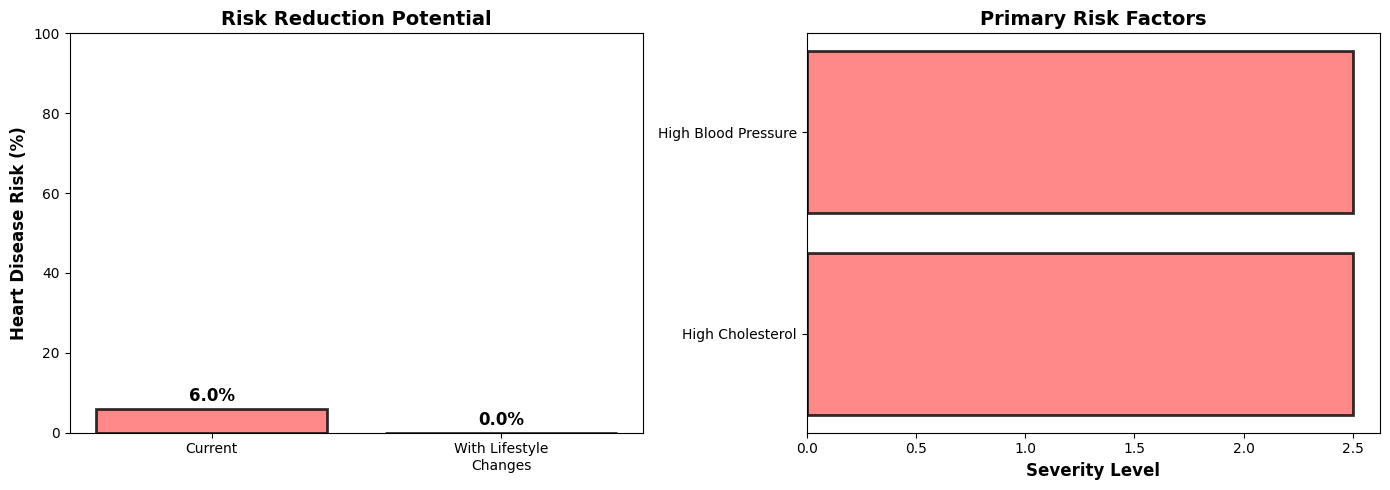


✅ NEXT STEPS:
1. Share this report with your healthcare provider
2. Schedule regular checkups (every 3-6 months)
3. Monitor your metrics and track improvements
4. Join support groups or online health communities
5. Review progress monthly and adjust plan as needed

⚠️  SEEK IMMEDIATE CARE IF:
  • Severe chest pain or pressure
  • Shortness of breath at rest
  • Fainting or severe dizziness
  • Sudden numbness or weakness


In [65]:
# 30-Day Action Plan & Risk Reduction Summary
import matplotlib.pyplot as plt
import numpy as np

# Create AI-generated action plan
action_plan = {
    'Week 1': {
        'title': 'Awareness & Assessment',
        'tasks': [
            '✓ Schedule cardiology appointment',
            '✓ Get baseline blood work (lipid panel, glucose)',
            '✓ Track diet, exercise, stress for 7 days',
            '✓ Download blood pressure/fitness tracking app'
        ]
    },
    'Week 2-3': {
        'title': 'Lifestyle Modifications',
        'tasks': [
            '✓ Start daily 30-minute moderate exercise (brisk walk)',
            '✓ Reduce sodium: avoid processed foods',
            '✓ Add 5+ servings fruits/vegetables daily',
            '✓ Implement stress-reduction: 10 mins meditation daily'
        ]
    },
    'Week 4': {
        'title': 'Optimization & Monitoring',
        'tasks': [
            '✓ Increase exercise intensity gradually',
            '✓ Recheck blood pressure and vitals',
            '✓ Review alcohol and caffeine intake',
            '✓ Plan follow-up doctor appointment'
        ]
    }
}

print('\n' + '='*70)
print('📋 30-DAY ACTION PLAN FOR HEART HEALTH')
print('='*70)
for week, plan in action_plan.items():
    print(f"\n{week}: {plan['title']}")
    for task in plan['tasks']:
        print(f"  {task}")

# Visualization: Risk Reduction Potential
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Chart 1: Before & After Risk
categories = ['Current', 'With Lifestyle\nChanges']
risks = [prob * 100, recommendations['improved_probability'] * 100]
colors = ['#FF6B6B', '#4ECDC4']
axes[0].bar(categories, risks, color=colors, alpha=0.8, edgecolor='black', linewidth=2)
axes[0].set_ylabel('Heart Disease Risk (%)', fontsize=12, fontweight='bold')
axes[0].set_ylim(0, 100)
axes[0].set_title('Risk Reduction Potential', fontsize=14, fontweight='bold')
for i, v in enumerate(risks):
    axes[0].text(i, v + 2, f'{v:.1f}%', ha='center', fontsize=12, fontweight='bold')

# Chart 2: Key Risk Factors
risk_factors = [item['factor'] for item in recommendations['high_risk'][:5]]
risk_severity = [2.5 for _ in risk_factors]  # Relative severity
if risk_factors:
    y_pos = np.arange(len(risk_factors))
    axes[1].barh(y_pos, risk_severity, color='#FF6B6B', alpha=0.8, edgecolor='black', linewidth=2)
    axes[1].set_yticks(y_pos)
    axes[1].set_yticklabels(risk_factors)
    axes[1].set_xlabel('Severity Level', fontsize=12, fontweight='bold')
    axes[1].set_title('Primary Risk Factors', fontsize=14, fontweight='bold')
    axes[1].invert_yaxis()
else:
    axes[1].text(0.5, 0.5, '✅ No Critical Risk Factors', ha='center', va='center', fontsize=14, transform=axes[1].transAxes)
    axes[1].axis('off')

plt.tight_layout()
plt.show()

print('\n' + '='*70)
print('✅ NEXT STEPS:')
print('='*70)
print('1. Share this report with your healthcare provider')
print('2. Schedule regular checkups (every 3-6 months)')
print('3. Monitor your metrics and track improvements')
print('4. Join support groups or online health communities')
print('5. Review progress monthly and adjust plan as needed')
print('\n⚠️  SEEK IMMEDIATE CARE IF:')
print('  • Severe chest pain or pressure')
print('  • Shortness of breath at rest')
print('  • Fainting or severe dizziness')
print('  • Sudden numbness or weakness')
print('='*70)

In [ ]:
# Generate Downloadable Health Report
from datetime import datetime

def generate_health_report(user_data, risk_prob, recommendations):
    """Generate a comprehensive health report"""
    report = []
    report.append('='*70)
    report.append('HEART DISEASE RISK ASSESSMENT REPORT')
    report.append('='*70)
    report.append(f'Generated: {datetime.now().strftime("%Y-%m-%d %H:%M:%S")}')
    report.append('')
    
    report.append('PATIENT INFORMATION')
    report.append('-'*70)
    report.append(f'Age: {user_data["Age"]} years')
    report.append(f'Sex: {"Male" if user_data["Sex"] == 1 else "Female"}')
    report.append(f'Resting Blood Pressure: {user_data["RestingBP"]} mmHg')
    report.append(f'Cholesterol: {user_data["Cholesterol"]} mg/dL')
    report.append(f'Max Heart Rate Achieved: {user_data["MaxHR"]} bpm')
    report.append('')
    
    report.append('RISK ASSESSMENT RESULTS')
    report.append('-'*70)
    report.append(f'Heart Disease Risk (Current): {risk_prob*100:.1f}%')
    report.append(f'Risk Level: {"HIGH" if risk_prob > 0.7 else "MODERATE" if risk_prob > 0.4 else "LOW"}')
    report.append(f'Potential Risk Reduction: {recommendations["estimated_improvement"]:.1f}%')
    report.append(f'Risk After Improvements: {recommendations["improved_probability"]*100:.1f}%')
    report.append('')
    
    report.append('RECOMMENDATIONS')
    report.append('-'*70)
    for item in recommendations['high_risk']:
        report.append(f'• {item["factor"]}')
        report.append(f'  Current: {item["current"]} | Target: {item["target"]}')
    report.append('')
    
    report.append('MEDICAL ADVICE')
    report.append('-'*70)
    report.append('1. Consult with a cardiologist for personalized medical advice')
    report.append('2. Implement lifestyle changes gradually but consistently')
    report.append('3. Monitor vital signs regularly')
    report.append('4. Keep all scheduled medical appointments')
    report.append('5. Report any new or worsening symptoms immediately')
    report.append('')
    report.append('DISCLAIMER: This report is for informational purposes only.')
    report.append('It should not replace professional medical advice.')
    report.append('='*70)
    
    return '\n'.join(report)

# Generate and display report
report_text = generate_health_report(user_data, prob, recommendations)
print(report_text)

# Save report to file (optional)
with open('heart_disease_risk_report.txt', 'w') as f:
    f.write(report_text)
print('\n✅ Report saved as: heart_disease_risk_report.txt')

In [66]:
# Export Models & Feature Info for Production
import joblib
import json

# Save the best XGBoost model
joblib.dump(xgb_grid.best_estimator_, 'xgb_model.pkl')
print('✅ XGBoost model saved as: xgb_model.pkl')

# Save the voting ensemble
joblib.dump(voting, 'voting_ensemble.pkl')
print('✅ Voting Ensemble model saved as: voting_ensemble.pkl')

# Save feature names and types for prediction
feature_info = {
    'feature_names': X.columns.tolist(),
    'feature_dtypes': {col: str(X[col].dtype) for col in X.columns},
    'feature_statistics': {
        'mean': X.mean().to_dict(),
        'median': X.median().to_dict(),
        'std': X.std().to_dict(),
        'min': X.min().to_dict(),
        'max': X.max().to_dict()
    },
    'categorical_features': categorical_cols
}

with open('feature_info.json', 'w') as f:
    json.dump(feature_info, f, indent=2)
print('✅ Feature info saved as: feature_info.json')

print('\n📦 PRODUCTION FILES READY:')
print('   - xgb_model.pkl (best XGBoost model)')
print('   - voting_ensemble.pkl (ensemble model)')
print('   - feature_info.json (feature metadata)')


✅ XGBoost model saved as: xgb_model.pkl
✅ Voting Ensemble model saved as: voting_ensemble.pkl
✅ Feature info saved as: feature_info.json

📦 PRODUCTION FILES READY:
   - xgb_model.pkl (best XGBoost model)
   - voting_ensemble.pkl (ensemble model)
   - feature_info.json (feature metadata)
